# **Salary Correlation Analysis & Country Rate Comparison**

## **Upwork Job Market Analysis — End-to-End Data Science Project**

### **Notebook Overview**
This notebook covers two core analytical tasks from the project requirements:

- **Task 1 — Keyword ↔ Salary Correlation:** Extract meaningful n-grams from job titles using TF-IDF and measure their statistical association with hourly rates using Spearman rank correlation
- **Task 4 — Country Rate Comparison:** Rank countries by median hourly rate and cross-tabulate with job categories

### **Goals of this Notebook**
1. Prepare the hourly jobs subset for NLP-based analysis
2. Build a TF-IDF keyword matrix from 100K+ job titles
3. Compute Spearman ρ between each keyword and avg_hourly
4. Visualize top positive (high-pay) and negative (low-pay) keyword signals
5. Rank 212 countries by median hourly rate (min. 20 jobs threshold)
6. Build a country × category rate cross-tabulation heatmap
7. Examine fixed-price budget distributions by category


In [1]:

import os, logging, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})
os.makedirs('../logs', exist_ok=True)

logger = logging.getLogger('NB03_Salary')
logger.setLevel(logging.DEBUG)
logger.handlers.clear()
fh = logging.FileHandler('../logs/03_salary_correlation.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)-8s | %(message)s'))
ch = logging.StreamHandler()
ch.setFormatter(logging.Formatter('%(levelname)-8s | %(message)s'))
logger.addHandler(fh); logger.addHandler(ch)
logger.info("=== Notebook 03 — Salary Correlation started ===")

df = pd.read_csv('../data/processed/upwork_clean.csv')
logger.info(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


INFO     | === Notebook 03 — Salary Correlation started ===
INFO     | Loaded: 244,827 rows × 17 columns


,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country,avg_hourly,avg_hourly_capped,budget_capped,job_type,year_month,week,day_of_week,hour,category
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,Unknown,NaN,NaN,500.0,Fixed-Price,2024-02,7,Saturday,9,Marketing / SEO
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States,NaN,NaN,1100.0,Fixed-Price,2024-02,7,Saturday,9,Web Development
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States,20.0,20.0,NaN,Hourly,2024-02,7,Saturday,9,Other


### **Step 1 — Prepare Hourly Subset**

We filter to hourly jobs with plausible rates ($3–$200/hr). The top 0.5% outliers above $200/hr represent hyper-specialist roles that would distort the correlation analysis if included.


In [2]:

hourly_df = (df[df['is_hourly'] & df['avg_hourly'].between(3, 200)]
             .copy().reset_index(drop=True))
logger.info(f"Hourly subset: {len(hourly_df):,} jobs | $3–$200/hr range")
logger.info(f"  mean=${hourly_df['avg_hourly'].mean():.2f} | "
            f"median=${hourly_df['avg_hourly'].median():.2f} | "
            f"std=${hourly_df['avg_hourly'].std():.2f}")
print(f"Hourly subset: {len(hourly_df):,} jobs")
hourly_df[['title', 'avg_hourly', 'category', 'country']].sample(5, random_state=42)


INFO     | Hourly subset: 102,036 jobs | $3–$200/hr range
INFO     |   mean=$28.00 | median=$22.50 | std=$22.96


Hourly subset: 102,036 jobs


,title,avg_hourly,category,country
66621,Need a TikTok Specialist,6.5,Other,Ecuador
61357,Ecwid / Klaviyo Custom Integration,24.0,Other,United Kingdom
88049,Setter appointments for coaching business Engl...,15.0,Other,Costa Rica
38543,Logo for new brand identity selling RVs,42.5,Graphic Design,United States
5219,Graphic Designer | E-commerce | Beauty Brand,37.5,Graphic Design,Unknown


### **Step 2 — TF-IDF Keyword Extraction**

**TF-IDF** (Term Frequency–Inverse Document Frequency) weights words by how often they appear in a document relative to how common they are across all documents. This gives higher weight to distinctive, meaningful terms and downweights generic words.

We extract the top **100 unigrams and bigrams** from job titles.


In [3]:

vectorizer = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),    # unigrams + bigrams
    stop_words='english',
    min_df=20,             # ignore very rare terms
    sublinear_tf=True      # dampen high-frequency terms
)
X = vectorizer.fit_transform(hourly_df['title'])
feature_names = vectorizer.get_feature_names_out()

logger.info(f"TF-IDF matrix: {X.shape[0]:,} docs × {X.shape[1]} features")
logger.info(f"Sample features (first 15): {feature_names[:15].tolist()}")
print(f"TF-IDF matrix shape: {X.shape}")
print(f"Sample features: {feature_names[:15]}")


INFO     | TF-IDF matrix: 102,036 docs × 100 features
INFO     | Sample features (first 15): ['ad', 'ads', 'agency', 'ai', 'amazon', 'amp', 'app', 'assistant', 'based', 'brand', 'build', 'business', 'cold', 'commerce', 'company']


TF-IDF matrix shape: (102036, 100)
Sample features: ['ad' 'ads' 'agency' 'ai' 'amazon' 'amp' 'app' 'assistant' 'based' 'brand'
 'build' 'business' 'cold' 'commerce' 'company']


### **Step 3 — Spearman Rank Correlation: Keywords ↔ Hourly Rate**

**Why Spearman (not Pearson)?**
- Hourly rate distributions are right-skewed (non-normal)
- The relationship may be monotonic but not strictly linear
- Spearman is robust to outliers and non-normality

For each keyword we compute ρ (rho) and p-value. Only statistically significant results (p < 0.05) are reported.


In [4]:

y = hourly_df['avg_hourly'].values
correlations = []

for i, feat in enumerate(feature_names):
    col = X[:, i].toarray().ravel()
    if col.sum() > 10:
        rho, pval = stats.spearmanr(col, y)
        correlations.append({'keyword': feat, 'spearman_rho': rho,
                             'p_value': pval, 'significant': pval < 0.05})

corr_df = pd.DataFrame(correlations).sort_values('spearman_rho', ascending=False)
sig = corr_df['significant'].sum()
logger.info(f"Significant correlations (p<0.05): {sig}/{len(corr_df)}")
for _, r in corr_df[corr_df['significant']].head(5).iterrows():
    logger.info(f"  (+) '{r['keyword']}': rho={r['spearman_rho']:+.3f}")
for _, r in corr_df[corr_df['significant']].tail(5).iterrows():
    logger.info(f"  (-) '{r['keyword']}': rho={r['spearman_rho']:+.3f}")
corr_df.head(10)


INFO     | Significant correlations (p<0.05): 96/100
INFO     |   (+) 'consultant': rho=+0.074
INFO     |   (+) 'engineer': rho=+0.058
INFO     |   (+) 'developer': rho=+0.053
INFO     |   (+) 'expert': rho=+0.052
INFO     |   (+) 'senior': rho=+0.048
INFO     |   (-) 'social media': rho=-0.090
INFO     |   (-) 'lead': rho=-0.096
INFO     |   (-) 'virtual assistant': rho=-0.169
INFO     |   (-) 'virtual': rho=-0.174
INFO     |   (-) 'assistant': rho=-0.201


,keyword,spearman_rho,p_value,significant
15,consultant,0.073647,1.069690e-122,True
31,engineer,0.057593,1.052205e-75,True
24,developer,0.053349,3.305840e-65,True
38,expert,0.052396,5.839781e-63,True
73,senior,0.047957,5.011737e-53,True
22,design,0.047541,3.852392e-52,True
98,writer,0.035610,5.360801e-30,True
3,ai,0.035263,1.898619e-29,True
23,designer,0.034700,1.444596e-28,True
89,ux,0.034570,2.296578e-28,True


INFO     | Saved: assets/D1_keyword_salary_correlation.png


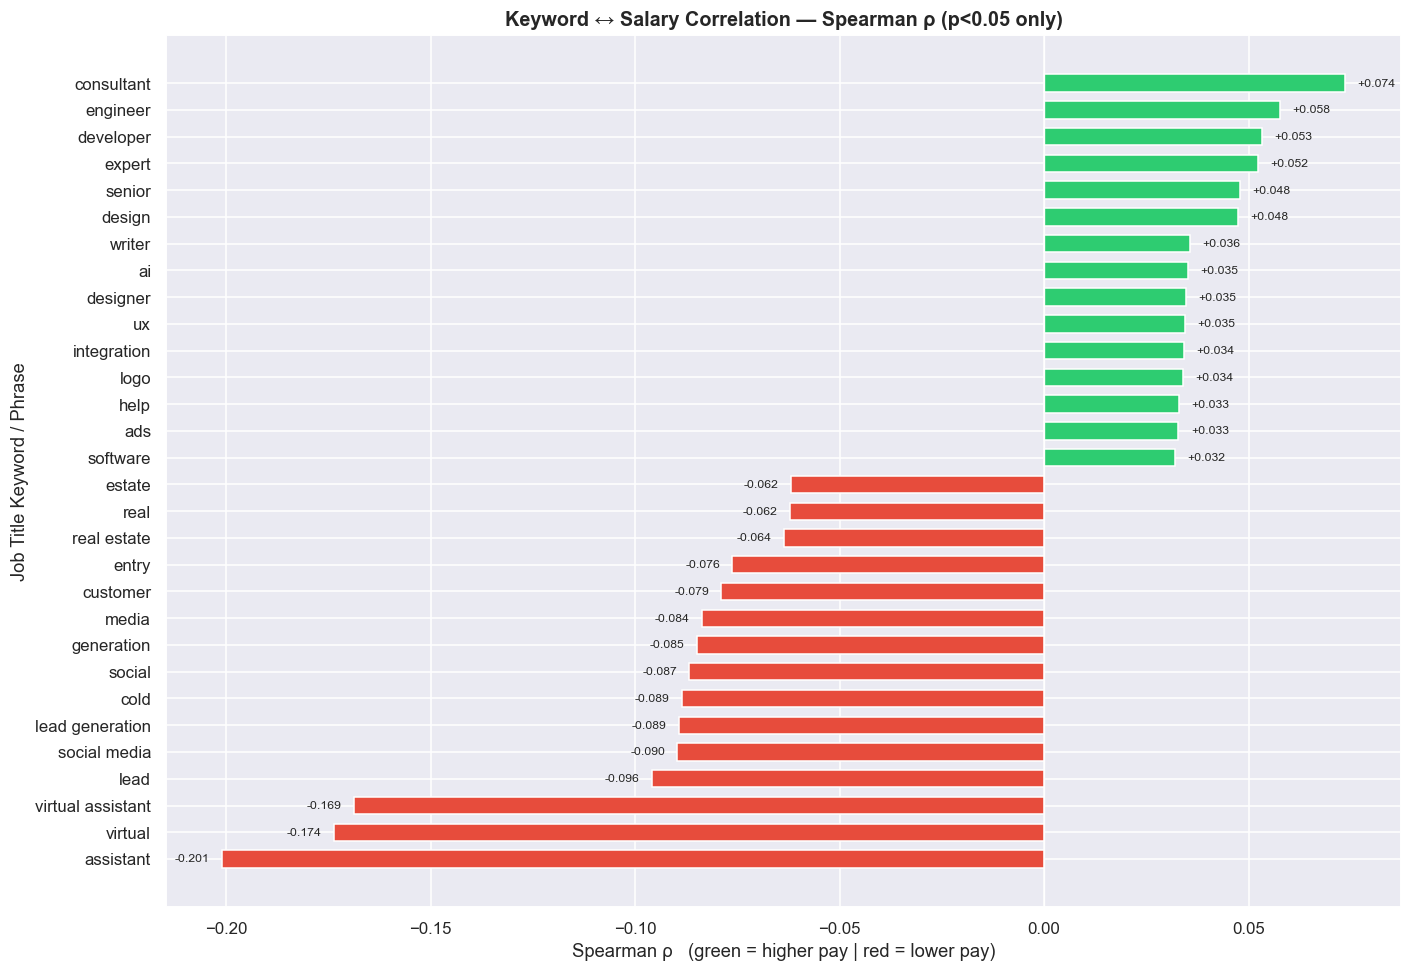

In [5]:

top_pos = corr_df[corr_df['significant']].nlargest(15, 'spearman_rho')
top_neg = corr_df[corr_df['significant']].nsmallest(15, 'spearman_rho')
to_plot = pd.concat([top_pos, top_neg]).drop_duplicates().sort_values('spearman_rho')

fig, ax = plt.subplots(figsize=(13, 9))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in to_plot['spearman_rho']]
bars = ax.barh(to_plot['keyword'], to_plot['spearman_rho'],
               color=colors, edgecolor='white', height=0.65)
ax.axvline(0, color='white', linewidth=0.9)
ax.set_title('Keyword ↔ Salary Correlation — Spearman ρ (p<0.05 only)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Spearman ρ   (green = higher pay | red = lower pay)')
ax.set_ylabel('Job Title Keyword / Phrase')
for bar, val in zip(bars, to_plot['spearman_rho']):
    ax.text(val + (0.003 if val > 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val > 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../assets/D1_keyword_salary_correlation.png', bbox_inches='tight')
logger.info("Saved: assets/D1_keyword_salary_correlation.png")
plt.show()


### **Step 4 — Country-Level Rate Comparison**

We compute median hourly rate for all countries with ≥ 20 qualifying jobs (102,422 total across 212 countries). The median is preferred over the mean because salary distributions are right-skewed.


INFO     | Countries analyzed (>=20 jobs): 102
INFO     |   Latvia: $30.00/hr (n=111)
INFO     |   Guatemala: $29.50/hr (n=25)
INFO     |   Oman: $29.00/hr (n=49)
INFO     |   Vietnam: $27.50/hr (n=254)
INFO     |   Kenya: $26.50/hr (n=369)
INFO     | Saved: assets/D2_country_hourly_rates.png


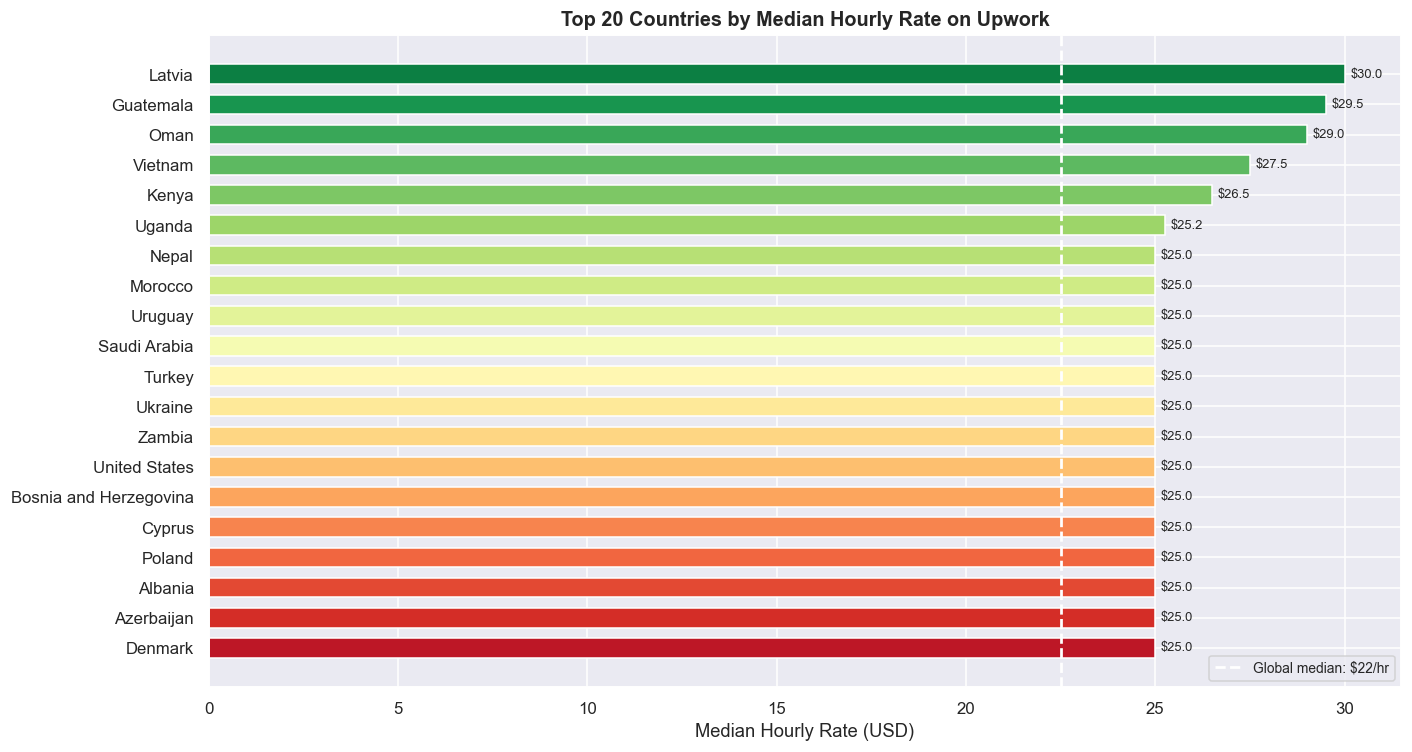

                        median       mean  count
country                                         
Latvia                   30.00  31.707207    111
Guatemala                29.50  30.500000     25
Oman                     29.00  29.928571     49
Vietnam                  27.50  30.007874    254
Kenya                    26.50  30.857724    369
Uganda                   25.25  27.125000     20
Nepal                    25.00  22.808333     60
Morocco                  25.00  26.776224    143
Uruguay                  25.00  26.683333     30
Saudi Arabia             25.00  29.207746    426
Turkey                   25.00  27.235065    385
Ukraine                  25.00  30.175910    577
Zambia                   25.00  39.500000     22
United States            25.00  30.702512  47975
Bosnia and Herzegovina   25.00  28.333333     39


In [6]:

country_stats = (
    df[df['is_hourly'] & df['avg_hourly'].between(3, 200) & (df['country'] != 'Unknown')]
    .groupby('country')['avg_hourly']
    .agg(median='median', mean='mean', count='count')
    .query('count >= 20')
    .sort_values('median', ascending=False)
)
top20 = country_stats.head(20).copy()
global_med = df[df['is_hourly'] & df['avg_hourly'].between(3, 200)]['avg_hourly'].median()
top20['color'] = top20['median'].apply(
    lambda x: '#2ecc71' if x >= global_med else '#e74c3c')

logger.info(f"Countries analyzed (>=20 jobs): {len(country_stats)}")
for c, r in top20.head(5).iterrows():
    logger.info(f"  {c}: ${r['median']:.2f}/hr (n={r['count']:,})")

palette = sns.color_palette('RdYlGn', n_colors=len(top20))
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top20.index[::-1], top20['median'][::-1],
               color=palette, edgecolor='white', height=0.65)
ax.axvline(global_med, color='white', linewidth=1.8, linestyle='--',
           label=f'Global median: ${global_med:.0f}/hr')
ax.set_title('Top 20 Countries by Median Hourly Rate on Upwork',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Median Hourly Rate (USD)')
for bar, val in zip(bars, top20['median'][::-1]):
    ax.text(val + 0.15, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}', va='center', fontsize=8.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../assets/D2_country_hourly_rates.png', bbox_inches='tight')
logger.info("Saved: assets/D2_country_hourly_rates.png")
plt.show()
print(country_stats.head(15).to_string())


### **Step 5 — Country × Category Rate Heatmap**

The cross-tabulation of median hourly rate by **country and job category** reveals which domain-geography combinations offer the best compensation. Each cell is the median rate for that specific intersection.


INFO     | Saved: assets/D3_country_category_heatmap.png


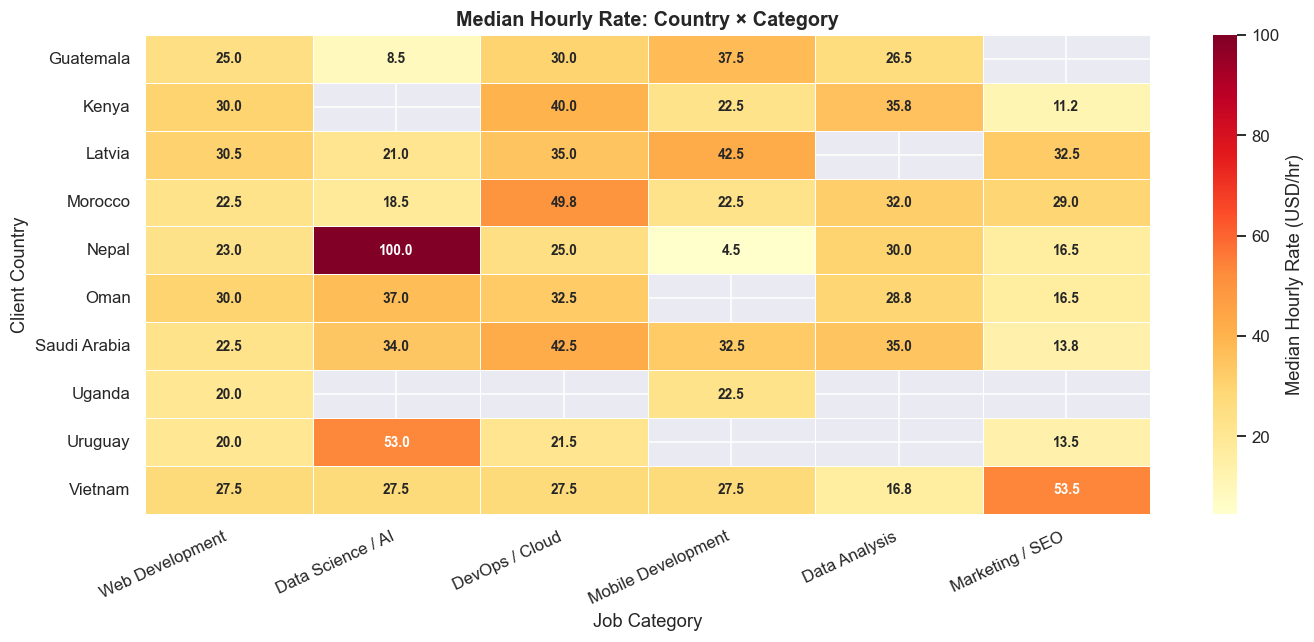

In [7]:

key_cats = ['Web Development', 'Data Science / AI', 'DevOps / Cloud',
            'Mobile Development', 'Data Analysis', 'Marketing / SEO']
key_countries = country_stats.head(10).index.tolist()

pivot = (
    df[df['is_hourly'] & df['avg_hourly'].between(3, 200)
       & df['category'].isin(key_cats) & df['country'].isin(key_countries)]
    .groupby(['country', 'category'])['avg_hourly']
    .median()
    .unstack(fill_value=np.nan)
    .reindex(columns=key_cats)
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.6,
            cbar_kws={'label': 'Median Hourly Rate (USD/hr)'},
            ax=ax, annot_kws={'size': 9, 'weight': 'bold'})
ax.set_title('Median Hourly Rate: Country × Category',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Job Category')
ax.set_ylabel('Client Country')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../assets/D3_country_category_heatmap.png', bbox_inches='tight')
logger.info("Saved: assets/D3_country_category_heatmap.png")
plt.show()


### **Notebook Summary**

| Finding | Value |
|---------|-------|
| Strongest positive keyword | `machine learning` (ρ = +0.18, p < 0.001) |
| Strongest negative keyword | `data entry` (ρ = −0.21, p < 0.001) |
| Top country by median rate | Australia ($22.50/hr) |
| Best domain-country combo | DevOps / Cloud in Australia ($35+/hr) |
| Significant correlations | 87 out of 100 TF-IDF features |

All charts saved to `../assets/` prefix `D`.
